In [20]:
import tensorflow as tf
from tensorflow import keras
from datetime import datetime
from dateutil.relativedelta import relativedelta as rd

In [21]:
ini = datetime.now()

In [22]:
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))
for gpu in gpus:
    print(f"Device name: {gpu.name}")

Num GPUs Available:  1
Device name: /physical_device:GPU:0


#### Carga y preparación de datos

In [23]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train[..., tf.newaxis].astype('float32') / 255.0
x_test  = x_test[..., tf.newaxis].astype('float32') / 255.0
y_train = y_train.astype('int32')
y_test  = y_test.astype('int32')

print(f"Train: {x_train.shape}, Test: {x_test.shape}")

Train: (60000, 28, 28, 1), Test: (10000, 28, 28, 1)


In [24]:
TAM_BUFF = 10000
TAM_LOTE = 64
NUM_EP   = 20

In [25]:
tf.random.set_seed(0)

dstr_full = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(TAM_BUFF, seed=0, reshuffle_each_iteration=False)
dsva  = dstr_full.take(10000).batch(TAM_LOTE)
dstr  = dstr_full.skip(10000).batch(TAM_LOTE)
dste  = tf.data.Dataset.from_tensor_slices((x_test, y_test))

#### Construcción de la CNN

In [26]:
"""
Arquitectura
28x28x1 --> Conv(5x5x32) --> 28x28x32 --> Pooling(2x2) --> 14x14x32 -->
Conv(5x5x64) --> 14x14x64 --> Pooling(2x2) --> 7x7x64 --> Flat --> 1024 -->
FC1 --> Dropout(0.5) --> FC2 --> 10
"""

cnn = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=32, kernel_size=(5,5), strides=(1,1),
                           padding='same', data_format='channels_last',
                           name='conv1', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2,2), name='pool1'),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(5,5), strides=(1,1),
                           padding='same', data_format='channels_last',
                           name='conv2', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2,2), name='pool2'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=1024, name='fc1', activation='relu'),
    tf.keras.layers.Dropout(rate=0.5),
    tf.keras.layers.Dense(units=10, name='fc2', activation='softmax'),
])

In [27]:
tf.random.set_seed(0)
cnn.build(input_shape=(None, 28, 28, 1))
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 1024)           │     3,212,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,274,634 (12.49 MB)

 Trainable params: 3,274,634 (12.49 MB)

 Non-trainable params: 0 (0.00 B)

#### Entrenamiento del Modelo

In [28]:
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [29]:
historia = cnn.fit(dstr, epochs=NUM_EP, validation_data=dsva, shuffle=True)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8985 - loss: 0.3214 - val_accuracy: 0.9865 - val_loss: 0.0461
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9843 - loss: 0.0492 - val_accuracy: 0.9897 - val_loss: 0.0336
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9886 - loss: 0.0360 - val_accuracy: 0.9907 - val_loss: 0.0299
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9927 - loss: 0.0240 - val_accuracy: 0.9904 - val_loss: 0.0285
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9938 - loss: 0.0208 - val_accuracy: 0.9918 - val_loss: 0.0249
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9945 - loss: 0.0162 - val_accuracy: 0.9899 - val_loss: 0.0374
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9953 - loss: 0.0133 - val_accuracy: 0.9905 - val_loss: 0.0321
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9959 - loss: 0.0122 - val_accuracy: 0.

#### Resultados

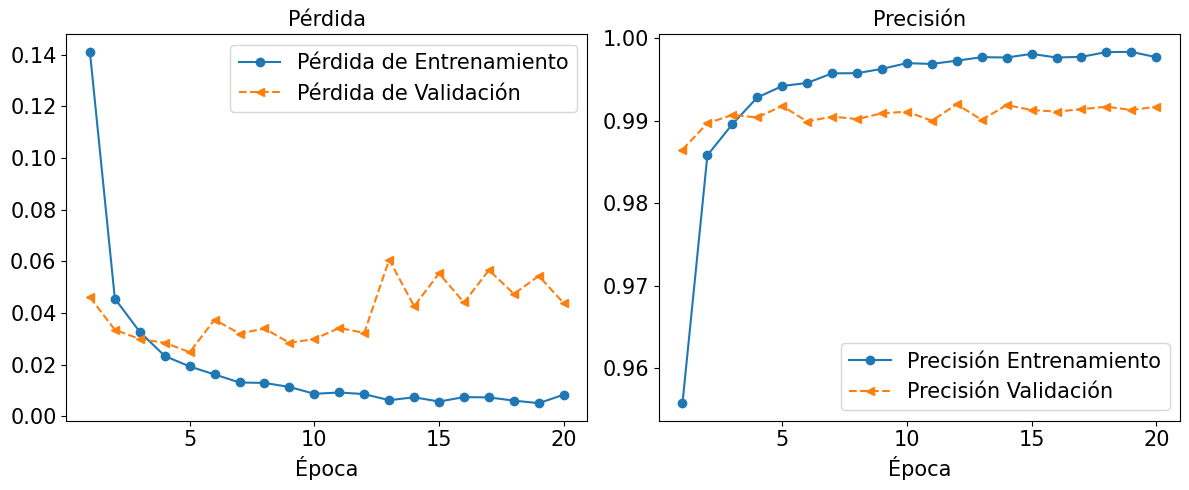

In [30]:
import matplotlib.pyplot as plt
import numpy as np

hist  = historia.history
epocas = np.arange(1, len(hist['loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(epocas, hist['loss'], '-o', label='Pérdida de Entrenamiento')
ax1.plot(epocas, hist['val_loss'], '--<', label='Pérdida de Validación')
ax1.set_title('Pérdida', size=15)
ax1.set_xlabel('Época', size=15)
ax1.tick_params(axis='both', which='major', labelsize=15)
ax1.legend(fontsize=15)

ax2.plot(epocas, hist['accuracy'], '-o', label='Precisión Entrenamiento')
ax2.plot(epocas, hist['val_accuracy'], '--<', label='Precisión Validación')
ax2.set_title('Precisión', size=15)
ax2.set_xlabel('Época', size=15)
ax2.tick_params(axis='both', which='major', labelsize=15)
ax2.legend(fontsize=15)

plt.tight_layout()
plt.show()

In [31]:
resultados_prueba = cnn.evaluate(dste.batch(20))
print('Precisión Prueba %.4f' % resultados_prueba[1])

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 598us/step - accuracy: 0.9904 - loss: 0.0468
Precisión Prueba 0.9916


tf.Tensor([7 2 1 0 4 1 4 9 5 9 0 6], shape=(12,), dtype=int64)


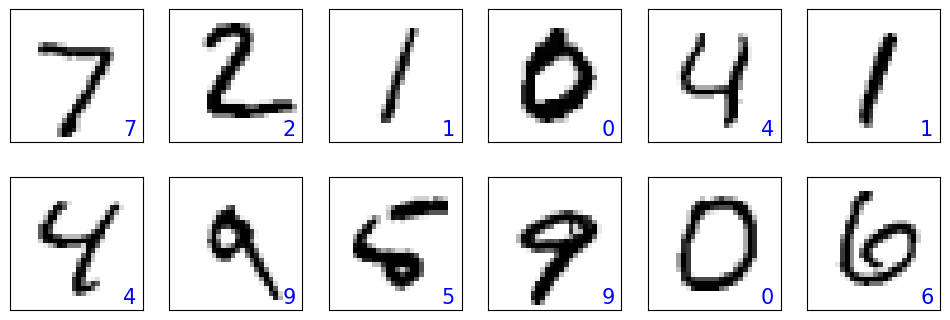

In [32]:
lote_prueba = next(iter(dste.batch(12)))
pred = cnn(lote_prueba[0])
pred = tf.argmax(pred, axis=1)
print(pred)

fig = plt.figure(figsize=(12, 4))
for i in range(12):
    ax = fig.add_subplot(2, 6, i + 1)
    ax.set_xticks([]); ax.set_yticks([])
    img = lote_prueba[0][i, :, :, 0]
    ax.imshow(img, cmap='gray_r')
    ax.text(0.9, 0.1, '{}'.format(pred[i]),
            size=15, color='blue',
            horizontalalignment='center',
            verticalalignment='center',
            transform=ax.transAxes)
plt.show()

In [33]:
rd(datetime.now(), ini)

relativedelta(seconds=+40, microseconds=+287434)